# Task 1 · Step 2 — Regularisation strength (β ∈ {0.03, 0.10, 0.30})

**Objective.** For a prompt $x$ with preferred / rejected responses $(y^+, y^-)$, a trainable policy $\pi_\theta$ and the frozen reference $\pi_{\text{ref}}$,
$$\mathcal{L}_{\text{DPO}}(\theta)=-\mathbb{E}\Big[\log\sigma\Big(\beta\Big[\log\tfrac{\pi_\theta(y^+|x)}{\pi_{\text{ref}}(y^+|x)}-\log\tfrac{\pi_\theta(y^-|x)}{\pi_{\text{ref}}(y^-|x)}\Big]\Big)\Big],$$
with sequence log-probabilities summed over response tokens only (teacher forcing).

**Setting.** Policy = `Qwen/Qwen2.5-1.5B-Instruct` + a fresh LoRA adapter (r = 8, α = 16, dropout 0.05, `q_proj`/`v_proj`); reference = the same network with the adapter disabled. AdamW, lr 2e-5, 2 pairs × 8 accumulation steps = 16 pairs per optimizer step, gradient clipping 1.0, seed 6304, fp16 on a T4.

**Sequence-length policy (TA clarification, 3 Oct).** Some prompt + response pairs exceed the 768-token limit. For every DPO training *and* evaluation run the prompt is kept intact and an over-length response is right-truncated (no EOS is appended to a cut response); pairs whose prompt leaves fewer than 64 response tokens are dropped. The same rule is used for all conditions.

**Protocol.** Three short forks from the same initialisation, trained on the same first 600 kept pairs of the standard split (38 optimizer steps), with identical data order, optimizer, seed and LoRA configuration — only β changes. All forks are evaluated with the same held-out pairs and the same generation protocol and seed. The standard one-epoch run (Step 1) uses a larger budget and is shown only as a labelled reference.

**Research question.** How does changing β alter preference fitting, KL from the reference policy and reward-model score? Is the relationship monotonic over the tested range?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets). `--skip-train` reuses fork adapters that already exist.


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task1_dpo.ablate_beta --config configs/dpo.yaml --skip-train')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. Training trajectories of the three forks

(curves omit 1 partial accumulation window(s): step 38 = 8 pairs)
(curves omit 1 partial accumulation window(s): step 38 = 8 pairs)
(curves omit 1 partial accumulation window(s): step 38 = 8 pairs)


,β=0.03,β=0.1,β=0.3
optimizer steps,38.000,38.0000,38.0000
pairs,600.000,600.0000,600.0000
wall-clock (min),8.100,8.2000,8.2000
final-5-step loss,0.691,0.6872,0.6749
final-5-step train acc,0.625,0.6380,0.6500


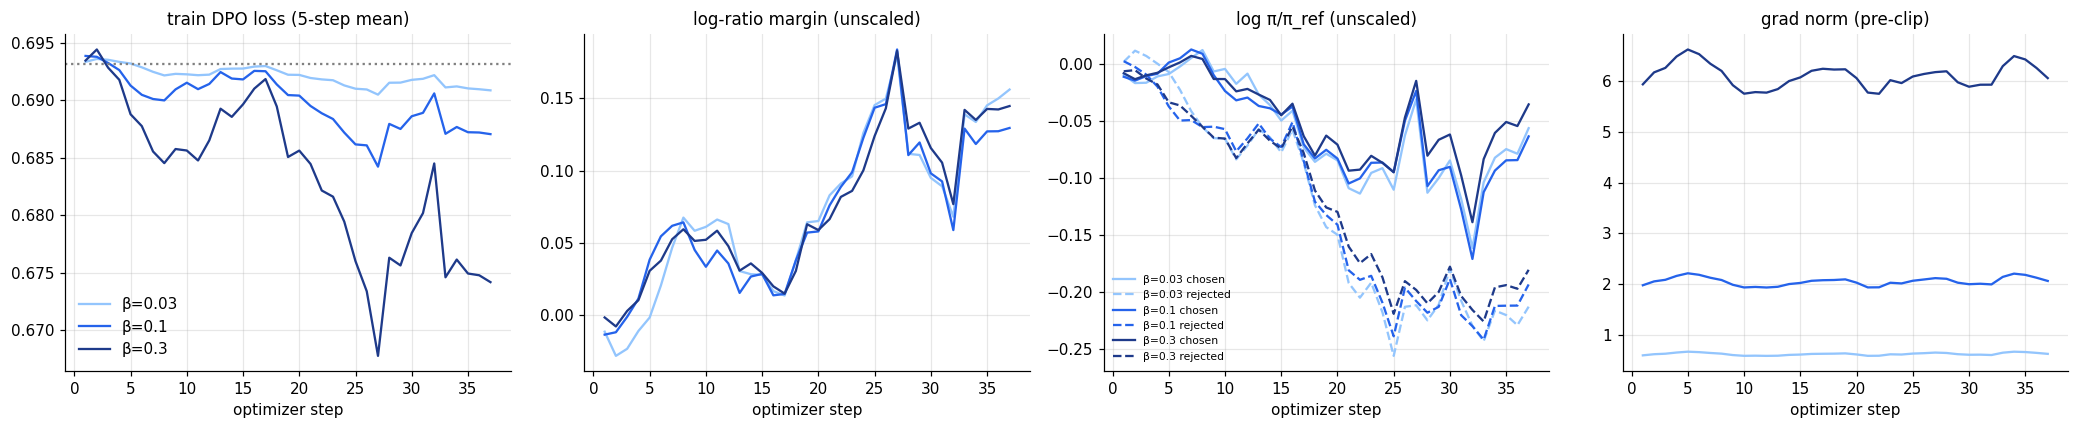

In [3]:
BETAS = [0.03, 0.10, 0.30]
name = lambda b: f"beta_{b:.2f}".replace(".", "_")
logs = {b: full_windows(pd.DataFrame(jl(f"task1_dpo/dpo_train_{name(b)}.jsonl"))) for b in BETAS}
summ = {b: load(f"task1_dpo/dpo_summary_{name(b)}.json") for b in BETAS}
display(pd.DataFrame({f"β={b:g}": {"optimizer steps": summ[b]["total_steps"], "pairs": summ[b]["dataset_size"],
                                   "wall-clock (min)": round(summ[b]["wall_time_seconds"] / 60, 1),
                                   "final-5-step loss": round(logs[b].loss.tail(5).mean(), 4),
                                   "final-5-step train acc": round(logs[b].preference_accuracy.tail(5).mean(), 3)} for b in BETAS}))
fig, ax = plt.subplots(1, 4, figsize=(19, 4))
for b, c in zip(BETAS, SEQ):
    L = logs[b]
    ax[0].plot(L.step, smooth(L.loss), color=c, label=f"β={b:g}")
    ax[1].plot(L.step, smooth(L.reward_margin_mean / L.beta), color=c, label=f"β={b:g}")
    ax[2].plot(L.step, smooth(L.implicit_chosen_reward_mean / L.beta), color=c, ls="-", label=f"β={b:g} chosen")
    ax[2].plot(L.step, smooth(L.implicit_rejected_reward_mean / L.beta), color=c, ls="--", label=f"β={b:g} rejected")
    ax[3].plot(L.step, smooth(L.grad_norm), color=c, label=f"β={b:g}")
for a, t in zip(ax, ["train DPO loss (5-step mean)", "log-ratio margin (unscaled)", "log π/π_ref (unscaled)", "grad norm (pre-clip)"]):
    a.set_title(t); a.set_xlabel("optimizer step")
ax[0].axhline(np.log(2), color="gray", ls=":"); ax[0].legend(); ax[2].legend(fontsize=7)
fig.tight_layout(); plt.show()

## 2. Held-out results
Held-out DPO loss is computed with each fork's own β, so its scale differs across rows; preference accuracy, margins, KL, RM and length are directly comparable.


In [4]:
E = {f"β={b:g} (600 pairs)": load(f"task1_dpo/dpo_eval_ablation_{name(b)}.json") for b in BETAS}
E_ref = {"SFT (no adapter)": load("task1_dpo/dpo_eval_sft_reference.json"), "standard β=0.10 (1 epoch)": load("task1_dpo/dpo_eval_standard.json")}
def row(e, sft=False):
    L = e["length_tokens"]
    return {"held-out loss (own β)": None if sft else e["heldout_dpo_loss"], "pref. accuracy": None if sft else e["heldout_preference_accuracy"],
            "mean margin": None if sft else e["mean_margin"], "KL token": e["kl_token_mean"], "KL seq": e["kl_sequence_mean"],
            "RM": e["mean_reward"], "RM s.e.m.": e["sem_reward"], "entropy": e["entropy_exact"],
            "length mean": L["mean"], "length IQR": L["iqr"], "EOS rate": e["eos_rate"]}
tab = pd.DataFrame({**{k: row(v) for k, v in E.items()}, **{k: row(v, k.startswith("SFT")) for k, v in E_ref.items()}}).T
tab.style.format(precision=4, na_rep="—")

,held-out loss (own β),pref. accuracy,mean margin,KL token,KL seq,RM,RM s.e.m.,entropy,length mean,length IQR,EOS rate
β=0.03 (600 pairs),0.6910,0.6055,0.1473,-0.0000,-0.0073,1.2817,0.0870,0.9474,160.9900,208.2500,0.5550
β=0.1 (600 pairs),0.6865,0.6367,0.1431,-0.0001,-0.0142,1.3302,0.0856,0.9482,160.4250,206.0000,0.5600
β=0.3 (600 pairs),0.6770,0.6298,0.1321,-0.0001,-0.0226,1.2599,0.0861,0.9448,160.0900,208.2500,0.5450
SFT (no adapter),—,—,—,0.0000,0.0000,1.2824,0.0863,0.9459,162.5850,206.0000,0.5500
standard β=0.10 (1 epoch),0.6752,0.6367,0.4231,0.0005,0.0819,1.2987,0.0852,0.9573,158.8350,207.0000,0.5700


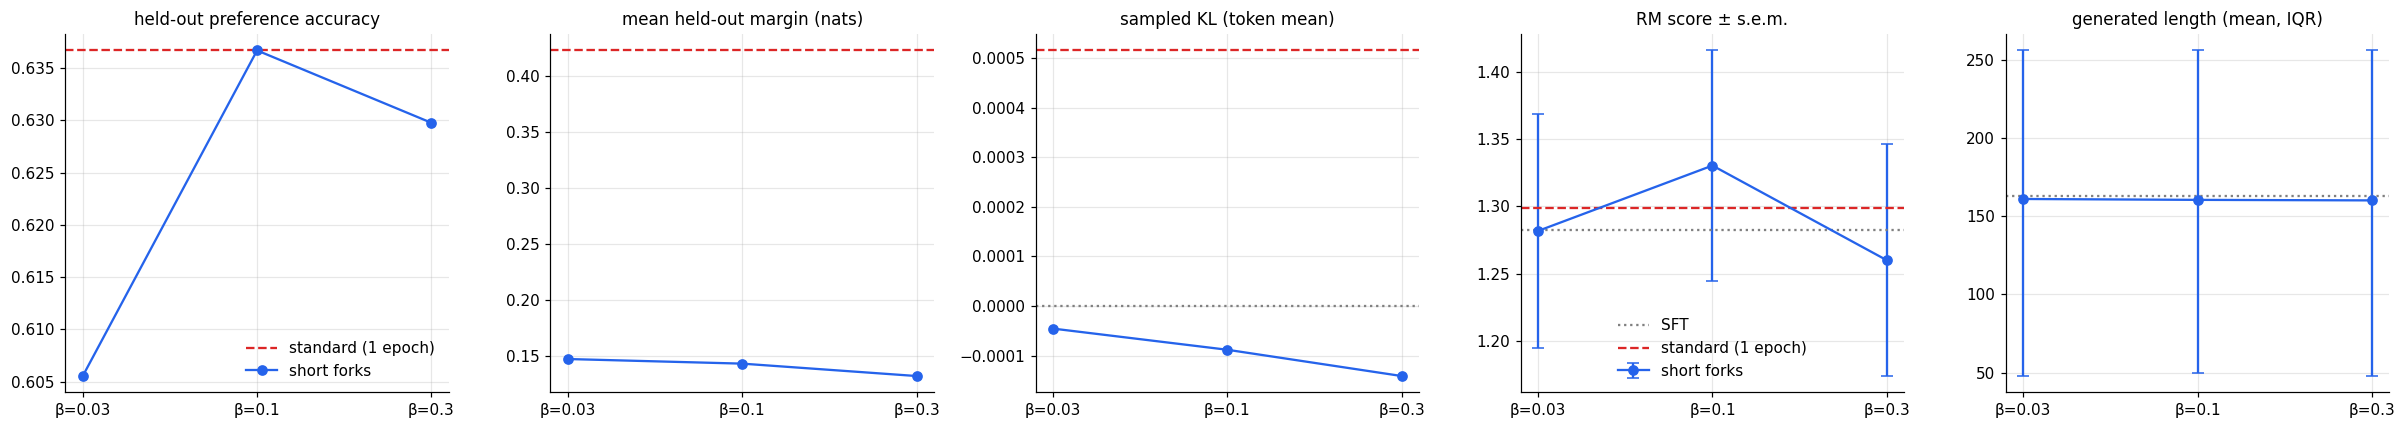

In [5]:
xs = np.arange(len(BETAS)); keys = list(E)
fig, ax = plt.subplots(1, 5, figsize=(22, 4))
for a, (k, t) in zip(ax, [("heldout_preference_accuracy", "held-out preference accuracy"), ("mean_margin", "mean held-out margin (nats)"),
                           ("kl_token_mean", "sampled KL (token mean)"), ("mean_reward", "RM score ± s.e.m."), (None, "generated length (mean, IQR)")]):
    if k is None:
        y = [E[q]["length_tokens"]["mean"] for q in keys]; lo = [E[q]["length_tokens"]["q25"] for q in keys]; hi = [E[q]["length_tokens"]["q75"] for q in keys]
        a.errorbar(xs, y, yerr=[np.array(y) - lo, np.array(hi) - y], fmt="o-", color="#2563EB", capsize=4)
        a.axhline(E_ref["SFT (no adapter)"]["length_tokens"]["mean"], color="gray", ls=":", label="SFT")
    else:
        y = [E[q][k] for q in keys]
        yerr = [E[q]["sem_reward"] for q in keys] if k == "mean_reward" else None
        a.errorbar(xs, y, yerr=yerr, fmt="o-", color="#2563EB", capsize=4, label="short forks")
        if k in ("kl_token_mean", "mean_reward"):
            a.axhline(E_ref["SFT (no adapter)"][k], color="gray", ls=":", label="SFT")
        a.axhline(E_ref["standard β=0.10 (1 epoch)"][k], color="#DC2626", ls="--", label="standard (1 epoch)")
    a.set_xticks(xs); a.set_xticklabels([f"β={b:g}" for b in BETAS]); a.set_title(t)
ax[0].legend(); ax[3].legend(); fig.tight_layout(); plt.show()

## 3. How different are the three fork models?
Correlation and sign agreement of the per-pair held-out margins between forks, and paired RM differences to SFT on the same prompts (bootstrap 95% CIs).


In [6]:
M = {b: np.array([p["margin"] for p in E[f"β={b:g} (600 pairs)"]["per_pair"]]) for b in BETAS}
rows = []
for a_, b_ in [(0.03, 0.10), (0.10, 0.30), (0.03, 0.30)]:
    rows.append({"pair": f"β={a_:g} vs β={b_:g}", "corr(margins)": np.corrcoef(M[a_], M[b_])[0, 1],
                 "sign agreement": np.mean((M[a_] > 0) == (M[b_] > 0)), "mean |margin| ratio": np.abs(M[b_]).mean() / np.abs(M[a_]).mean()})
display(pd.DataFrame(rows).set_index("pair").round(4))
sft_g = pd.DataFrame(E_ref["SFT (no adapter)"]["generations"]).set_index("prompt_id")
rows = []
for k, e in {**E, "standard β=0.10 (1 epoch)": E_ref["standard β=0.10 (1 epoch)"]}.items():
    g = pd.DataFrame(e["generations"]).set_index("prompt_id").loc[sft_g.index]
    d, lo, hi = bootstrap_mean_diff(g.reward_score, sft_g.reward_score)
    rows.append({"condition": k, "RM − SFT": d, "95% CI low": lo, "95% CI high": hi,
                 "identical text to SFT": (g.response == sft_g.response).mean()})
pd.DataFrame(rows).set_index("condition").round(4)

,corr(margins),sign agreement,mean |margin| ratio
pair,,,
β=0.03 vs β=0.1,0.9823,0.9481,0.9765
β=0.1 vs β=0.3,0.9776,0.9377,0.8972
β=0.03 vs β=0.3,0.9745,0.9619,0.8761


,RM − SFT,95% CI low,95% CI high,identical text to SFT
condition,,,,
β=0.03 (600 pairs),-0.0008,-0.0744,0.0708,0.605
β=0.1 (600 pairs),0.0478,-0.0235,0.1176,0.590
β=0.3 (600 pairs),-0.0225,-0.1019,0.0546,0.580
standard β=0.10 (1 epoch),0.0163,-0.0862,0.1219,0.345


## 4. Evidence for RQ1 (facts only)

In [7]:
for q in ["heldout_preference_accuracy", "mean_margin", "kl_token_mean", "mean_reward"]:
    vals = [E[f"β={b:g} (600 pairs)"][q] for b in BETAS]
    trend = "increasing" if np.all(np.diff(vals) > 0) else "decreasing" if np.all(np.diff(vals) < 0) else "non-monotonic"
    print(f"{q:30s} " + "  ".join(f"β={b:g}: {v:+.4f}" for b, v in zip(BETAS, vals)) + f"   -> {trend} over β")
print("RM s.e.m. per fork:", ", ".join(f"{E[k]['sem_reward']:.3f}" for k in E))

heldout_preference_accuracy    β=0.03: +0.6055  β=0.1: +0.6367  β=0.3: +0.6298   -> non-monotonic over β
mean_margin                    β=0.03: +0.1473  β=0.1: +0.1431  β=0.3: +0.1321   -> decreasing over β
kl_token_mean                  β=0.03: -0.0000  β=0.1: -0.0001  β=0.3: -0.0001   -> decreasing over β
mean_reward                    β=0.03: +1.2817  β=0.1: +1.3302  β=0.3: +1.2599   -> non-monotonic over β
RM s.e.m. per fork: 0.087, 0.086, 0.086
